# BIST KAP Bildirimleri — Event Study Analizi

**Amaç:** `src/analysis/event_study.py` modülünü 232 KAP bildirimi üzerinde uygulayıp:
- Hisse bazında CAR (Cumulative Abnormal Return) dağılımı
- İstatistiksel anlamlılık (t-test + sign test)
- Zamanlama farkı: aynı-gün vs. ertesi-gün etki
- AR profili (pencere içinde saat saat hareket)
- En büyük ±CAR olaylarının haberleri

**Pencere:** `t-1, t, t+1, t+2, t+3` (saatlik bar). **Baz model:** olay öncesi 60 bar sabit ortalama. EDA bulgularına göre ACF lag-1 ≈ 0 olduğu için pazar modeli (BIST100) gerekmedi.


In [1]:
from __future__ import annotations
import sys
from pathlib import Path

_here = Path.cwd()
_project_root = _here if (_here / "src").exists() else _here.parent
if str(_project_root) not in sys.path:
    sys.path.insert(0, str(_project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from src.config import TICKERS, BIST_TIMEZONE
from src.analysis.loaders import load_all_prices, load_all_disclosures
from src.analysis.event_study import run_event_study_multi

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 4)
pd.set_option("display.precision", 4)
print(f"Hisseler: {list(TICKERS)}")


Hisseler: ['THYAO', 'ASELS', 'GARAN', 'KCHOL', 'EREGL']


In [2]:
prices = load_all_prices()
news = load_all_disclosures()

# Default: before=1, after=3, est=60
results = run_event_study_multi(prices, news, before=1, after=3, estimation_window=60)

print(f"Toplam olay: {len(results)}")
print()
print("Status dagilim:")
print(results["status"].value_counts().to_string())


Toplam olay: 232

Status dagilim:
status
ok                           221
skipped:insufficient_data      9
skipped:no_bar                 2


## 1. CAR Genel Görünüm


In [3]:
ok = results[results["status"] == "ok"].copy()
print(f"OK olay: {len(ok)} / toplam {len(results)} ({len(ok)/len(results)*100:.1f}%)")
print()
ok.groupby("ticker")["car"].describe().round(5)


OK olay: 221 / toplam 232 (95.3%)



,count,mean,std,min,25%,50%,75%,max
ticker,,,,,,,,
ASELS,19.0,0.0043,0.0185,-0.0221,-0.0099,-0.0022,0.0246,0.0369
EREGL,22.0,0.0026,0.0186,-0.0536,0.0012,0.0028,0.0111,0.0318
GARAN,111.0,-0.0008,0.0193,-0.0630,-0.0116,-0.0015,0.0146,0.0389
KCHOL,41.0,0.0043,0.0138,-0.0160,-0.0069,0.0060,0.0158,0.0297
THYAO,28.0,0.0028,0.0209,-0.0525,-0.0086,0.0027,0.0119,0.0662


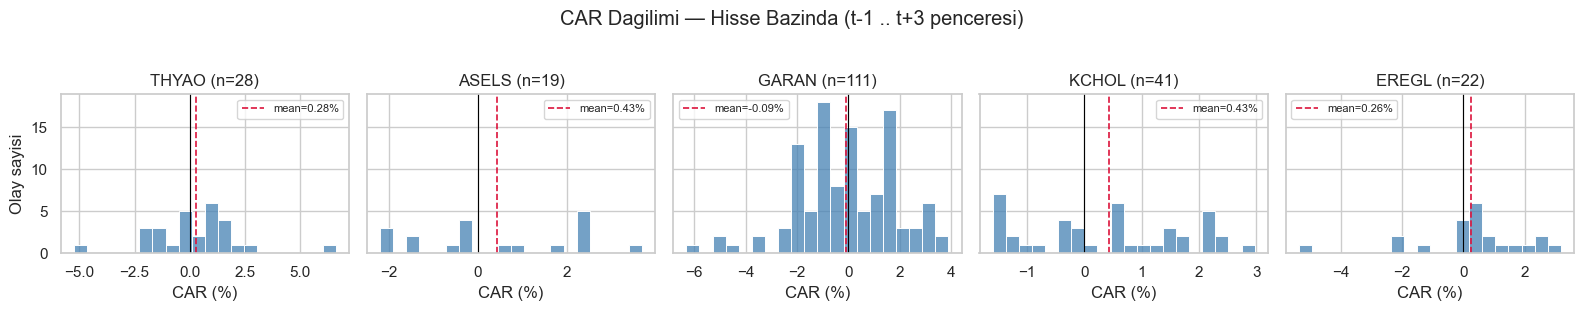

In [4]:
fig, axes = plt.subplots(1, len(TICKERS), figsize=(3.2 * len(TICKERS), 3), sharey=True)
for ax, t in zip(axes, TICKERS):
    car_series = ok[ok["ticker"] == t]["car"] * 100  # yuzdeye cevir
    if len(car_series) == 0:
        ax.set_title(f"{t}\n(veri yok)")
        continue
    sns.histplot(car_series, bins=20, ax=ax, color="steelblue", edgecolor=None)
    ax.axvline(0, color="black", lw=0.8)
    ax.axvline(car_series.mean(), color="crimson", lw=1.2, linestyle="--",
               label=f"mean={car_series.mean():.2f}%")
    ax.set_title(f"{t} (n={len(car_series)})")
    ax.set_xlabel("CAR (%)")
    ax.legend(fontsize=8)
axes[0].set_ylabel("Olay sayisi")
plt.suptitle("CAR Dagilimi — Hisse Bazinda (t-1 .. t+3 penceresi)", y=1.03)
plt.tight_layout()
plt.show()


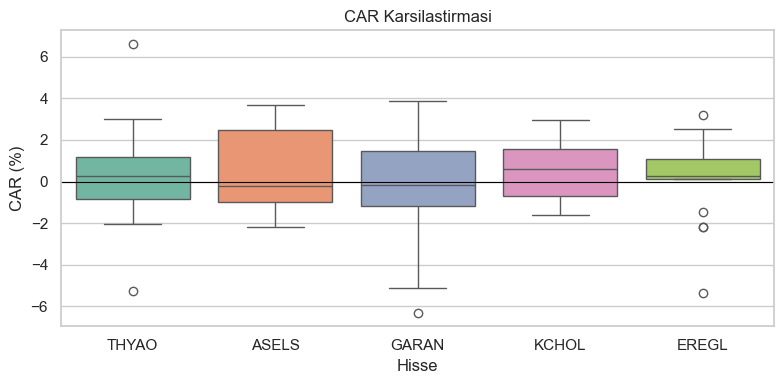

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
ok_plot = ok.assign(car_pct=ok["car"] * 100)
sns.boxplot(data=ok_plot, x="ticker", y="car_pct", ax=ax,
            hue="ticker", palette="Set2", legend=False)
ax.axhline(0, color="black", lw=0.8)
ax.set_title("CAR Karsilastirmasi")
ax.set_ylabel("CAR (%)")
ax.set_xlabel("Hisse")
plt.tight_layout()
plt.show()


## 2. İstatistiksel Anlamlılık

**H₀:** CAR ortalaması 0 (bildirim sonrası anlamlı bir fiyat hareketi yok).

- **t-test (1-örnek):** parametrik, normallik varsayar.
- **Sign test (binom):** non-parametrik, sadece pozitif/negatif sayısına bakar — outlier'a dayanıklı.

p < 0.05 → anlamlı; p < 0.10 → marjinal.


In [6]:
def ttest_and_sign(car_series: pd.Series) -> dict:
    car_clean = car_series.dropna()
    n = len(car_clean)
    if n < 2:
        return {"n": n, "mean_%": np.nan, "std_%": np.nan, "t_stat": np.nan,
                "p_t": np.nan, "n_pos": 0, "ratio_pos": np.nan, "p_sign": np.nan}
    t_stat, p_t = stats.ttest_1samp(car_clean, 0.0)
    n_pos = int((car_clean > 0).sum())
    sign_res = stats.binomtest(n_pos, n, p=0.5, alternative="two-sided")
    return {
        "n": n,
        "mean_%": car_clean.mean() * 100,
        "std_%": car_clean.std() * 100,
        "t_stat": t_stat,
        "p_t": p_t,
        "n_pos": n_pos,
        "ratio_pos": n_pos / n,
        "p_sign": sign_res.pvalue,
    }


rows = {t: ttest_and_sign(ok[ok["ticker"] == t]["car"]) for t in TICKERS}
rows["ALL"] = ttest_and_sign(ok["car"])
stats_table = pd.DataFrame(rows).T.round(4)
stats_table


,n,mean_%,std_%,t_stat,p_t,n_pos,ratio_pos,p_sign
THYAO,28.0,0.2812,2.0902,0.7120,0.4826,16.0,0.5714,0.5716
ASELS,19.0,0.4316,1.8488,1.0177,0.3223,9.0,0.4737,1.0000
GARAN,111.0,-0.0850,1.9315,-0.4637,0.6438,52.0,0.4685,0.5692
KCHOL,41.0,0.4274,1.3854,1.9753,0.0552,23.0,0.5610,0.5327
EREGL,22.0,0.2568,1.8559,0.6491,0.5233,18.0,0.8182,0.0043
ALL,221.0,0.1349,1.8469,1.0858,0.2788,118.0,0.5339,0.3463


## 3. Zamanlama: Aynı-gün vs Ertesi-gün Etki

EDA'da KAP bildirimlerinin %81.5'inin işlem saatleri dışında olduğunu görmüştük. `find_event_bar` bunları ertesi günün açılış bar'ına (09:30) maps ediyor. Soru: **CAR farklı mı?**


In [7]:
# Aynı gun olarak mi maps edildi yoksa ertesi gune mi?
ok["event_date"] = pd.to_datetime(ok["event_time"]).dt.date
ok["mapped_date"] = pd.to_datetime(ok["mapped_bar"]).dt.date
ok["same_day"] = ok["event_date"] == ok["mapped_date"]
ok["timing"] = np.where(ok["same_day"], "ayni-gun", "ertesi-gun")

print("Timing dagilim:")
print(ok["timing"].value_counts().to_string())
print()
print("Timing x ticker:")
print(pd.crosstab(ok["timing"], ok["ticker"]))
print()
print("CAR by timing:")
ok.groupby("timing")["car"].describe().round(5)


Timing dagilim:
timing
ayni-gun      153
ertesi-gun     68

Timing x ticker:
ticker      ASELS  EREGL  GARAN  KCHOL  THYAO
timing                                       
ayni-gun       13     15     86     26     13
ertesi-gun      6      7     25     15     15

CAR by timing:


,count,mean,std,min,25%,50%,75%,max
timing,,,,,,,,
ayni-gun,153.0,-0.0014,0.0172,-0.0536,-0.0136,-0.0023,0.0102,0.0389
ertesi-gun,68.0,0.0076,0.0198,-0.0630,-0.0004,0.0093,0.0198,0.0662


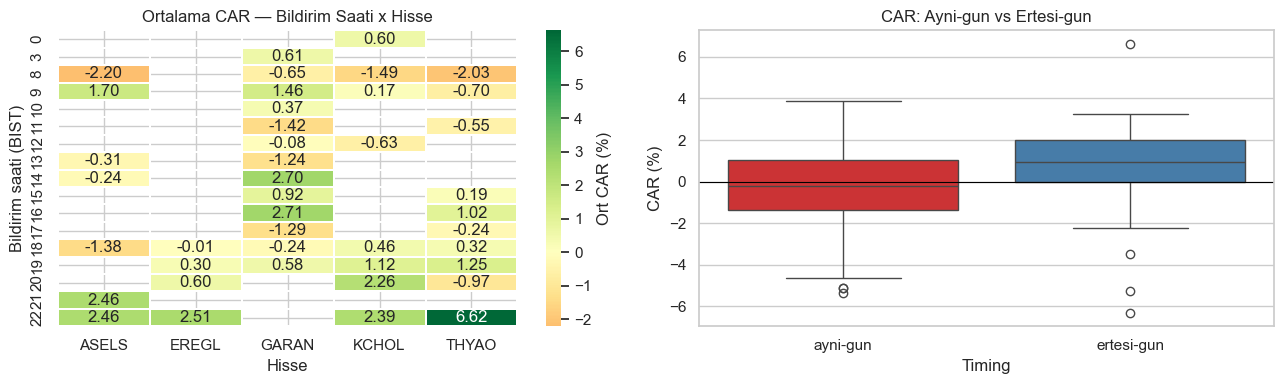

Ayni-gun  (n=153): ort CAR = %-0.141
Ertesi-gun(n= 68): ort CAR = %+0.756
Welch t-test (ayni vs ertesi): t = -3.231, p = 0.0016


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Sol: heatmap (event_hour x ticker)
ok["event_hour"] = pd.to_datetime(ok["event_time"]).dt.hour
pivot = ok.groupby(["event_hour", "ticker"])["car"].mean().unstack() * 100
sns.heatmap(pivot, cmap="RdYlGn", center=0, ax=axes[0], annot=True, fmt=".2f",
            cbar_kws={"label": "Ort CAR (%)"}, linewidths=0.3)
axes[0].set_title("Ortalama CAR — Bildirim Saati x Hisse")
axes[0].set_xlabel("Hisse")
axes[0].set_ylabel("Bildirim saati (BIST)")

# Sag: timing boxplot
ok_plot = ok.assign(car_pct=ok["car"] * 100)
sns.boxplot(data=ok_plot, x="timing", y="car_pct", ax=axes[1],
            hue="timing", palette="Set1", legend=False)
axes[1].axhline(0, color="black", lw=0.8)
axes[1].set_title("CAR: Ayni-gun vs Ertesi-gun")
axes[1].set_ylabel("CAR (%)")
axes[1].set_xlabel("Timing")

plt.tight_layout()
plt.show()

# Welch t-test
same_day = ok[ok["timing"] == "ayni-gun"]["car"].dropna()
next_day = ok[ok["timing"] == "ertesi-gun"]["car"].dropna()
if len(same_day) > 1 and len(next_day) > 1:
    t, p = stats.ttest_ind(same_day, next_day, equal_var=False)
    print(f"Ayni-gun  (n={len(same_day):3d}): ort CAR = %{same_day.mean()*100:+.3f}")
    print(f"Ertesi-gun(n={len(next_day):3d}): ort CAR = %{next_day.mean()*100:+.3f}")
    print(f"Welch t-test (ayni vs ertesi): t = {t:+.3f}, p = {p:.4f}")


## 4. AR Profili — Pencere İçinde Saat Saat Hareket

Olay öncesi/sonrası AR'lar yön ve büyüklük olarak nasıl dağılıyor? Bildirim öncesi drift (sızıntı?) veya bildirim sonrası geri çekilme (overshoot?) görülebilir.


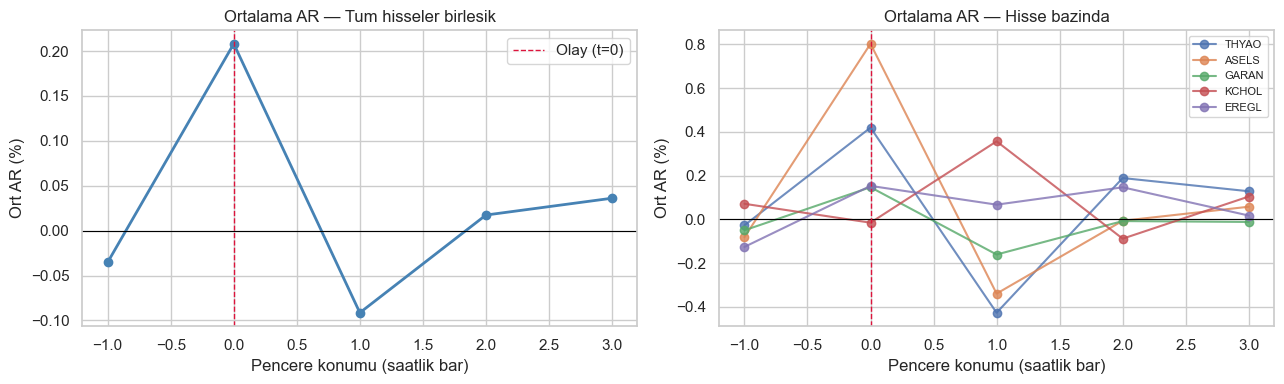

In [9]:
ar_cols = [c for c in ok.columns if c.startswith("ar_t")]
ar_long = ok[["ticker"] + ar_cols].melt(id_vars="ticker", var_name="offset", value_name="ar")
ar_long["offset_int"] = ar_long["offset"].str.replace("ar_t", "").astype(int)

mean_ar_overall = ar_long.groupby("offset_int")["ar"].mean() * 100  # %
mean_ar_by_ticker = ar_long.groupby(["offset_int", "ticker"])["ar"].mean().unstack() * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Sol: tum hisseler birlesik
axes[0].plot(mean_ar_overall.index, mean_ar_overall.values, marker="o", color="steelblue", lw=2)
axes[0].axhline(0, color="black", lw=0.8)
axes[0].axvline(0, color="crimson", lw=1, linestyle="--", label="Olay (t=0)")
axes[0].set_title("Ortalama AR — Tum hisseler birlesik")
axes[0].set_xlabel("Pencere konumu (saatlik bar)")
axes[0].set_ylabel("Ort AR (%)")
axes[0].legend()

# Sag: hisse bazli
for t in TICKERS:
    axes[1].plot(mean_ar_by_ticker.index, mean_ar_by_ticker[t], marker="o", label=t, alpha=0.8)
axes[1].axhline(0, color="black", lw=0.8)
axes[1].axvline(0, color="crimson", lw=1, linestyle="--")
axes[1].set_title("Ortalama AR — Hisse bazinda")
axes[1].set_xlabel("Pencere konumu (saatlik bar)")
axes[1].set_ylabel("Ort AR (%)")
axes[1].legend(loc="best", fontsize=8)

plt.tight_layout()
plt.show()


## 5. Olay-Spesifik Insights — En Büyük ±5 CAR


In [10]:
# event_idx ile news'e join et (subject + summary icin)
news_meta = news[["subject", "summary"]].copy()
ok_joined = ok.merge(news_meta, left_on="event_idx", right_index=True, how="left")

top_pos = ok_joined.nlargest(5, "car")[["ticker", "event_time", "car", "subject", "summary"]]
top_neg = ok_joined.nsmallest(5, "car")[["ticker", "event_time", "car", "subject", "summary"]]

def _print_block(title, df):
    print(f"=== {title} ===")
    for _, row in df.iterrows():
        print(f"  {row['ticker']} | {row['event_time']} | CAR = %{row['car']*100:+.2f}")
        print(f"    Subject: {row['subject']}")
        if isinstance(row['summary'], str) and row['summary'].strip():
            print(f"    Summary: {row['summary'][:120]}")
        print()

_print_block("En buyuk 5 pozitif CAR", top_pos)
_print_block("En buyuk 5 negatif CAR", top_neg)


=== En buyuk 5 pozitif CAR ===
  THYAO | 2026-03-09 22:39:45+03:00 | CAR = %+6.62
    Subject: Özel Durum Açıklaması (Genel)
    Summary: Şubat 2026 Trafik Sonuçları

  GARAN | 2026-01-22 18:14:27+03:00 | CAR = %+3.90
    Subject: Pay Dışında Sermaye Piyasası Aracı İşlemlerine İlişkin Bildirim (Faiz İçeren)
    Summary: Yurtdışı Piyasalara Tahvil İhracı SPK Onayı

  GARAN | 2026-01-22 18:14:40+03:00 | CAR = %+3.90
    Subject: Pay Dışında Sermaye Piyasası Aracı İşlemlerine İlişkin Bildirim (Faiz İçeren)
    Summary: MTN ihracı itfası 

  ASELS | 2026-01-26 09:27:31+03:00 | CAR = %+3.69
    Subject: Yeni İş İlişkisi
    Summary: Sözleşme İmzalanması 

  GARAN | 2026-01-16 18:13:26+03:00 | CAR = %+3.28
    Subject: Pay Dışında Sermaye Piyasası Aracı İşlemlerine İlişkin Bildirim (Faiz İçeren)
    Summary: MTN ihracı itfası 

=== En buyuk 5 negatif CAR ===
  GARAN | 2026-02-27 18:44:53+03:00 | CAR = %-6.31
    Subject: Yatırım Kuruluşu Varant - Sertifika - Senetlerine İlişkin Bildirim
    

## 6. Özet Bulgular (run sonrası doldur)

Notebook çalıştığında somut p-değerleri ve gözlemler:

| Boyut | Bulgu | Yorum |
|---|---|---|
| Toplam ok / toplam | (Bölüm 1) | data kapsama oranı |
| Ortalama CAR (ALL) | (Bölüm 2 stats_table 'ALL' satırı) | hangi yönde, ne büyüklükte |
| t-test p-değeri (ALL) | (Bölüm 2) | <0.05 → CAR ≠ 0 anlamlı |
| Sign test p-değeri (ALL) | (Bölüm 2) | parametrik dışı doğrulama |
| Aynı-gun vs Ertesi-gun | (Bölüm 3 Welch t-test) | EDA hipotezi: ertesi-gun gap baskın mı? |
| AR profili şekli | (Bölüm 4 grafik) | t=0'da sıçrama mı? Pre-event drift? Post-event reversal? |
| En büyük olaylar | (Bölüm 5) | bilgilendirici subject'ler — sentiment modelinin hedeflemesi için |

**Sonraki adımlar:**
- Sentiment skorlama → her bildirime polarite, CAR ile korelasyon
- Streamlit dashboard → bu analizleri interaktif hale getir
- (opsiyonel) Geniş pencere (t+1d, t+5d) ve BIST100 baz model karşılaştırması
